<img src="https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@5a33b79/ressources/img/logo_macmia.png" alt="Banque des Territoires · France 2030 · MACMIA" width="520">

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc3_stats/exercices/seance2_exercices.ipynb)

# Séance 3.2 — Comparer deux groupes — hasard ou vrai écart ?

**Exercices** · durée : 2h (≈50 min de cours, ≈50 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- expliquer pourquoi une moyenne calculée sur un échantillon n'est jamais exacte
- construire un intervalle de confiance à 95 % par rééchantillonnage
- comparer deux groupes avec un test t et lire sa p-value
- distinguer « pas de différence » de « pas de différence détectable »
- repérer les deux pièges qui rendent un test faux : dépendance des observations et tests répétés

## Comment ça marche

La feuille compte **deux parties**, à faire dans l'ordre.

**Partie 1 — l'échauffement.** Le code est déjà écrit, il ne reste que les `____` à
remplir. Chaque exercice se termine par une cellule de **vérification** qui vous dit
immédiatement si votre réponse est bonne.

**Partie 2 — les questions.** Une question, une cellule **vide** : à vous d'écrire le
code entier. Il n'y a pas de vérification automatique — on les corrige ensemble en
séance, et la correction est publiée après.

> ⚠️ Si une vérification de la partie 1 affiche `NameError`, c'est que la cellule
au-dessus n'a pas été exécutée, ou qu'il y reste un `____`. Complétez-la, relancez-la,
puis relancez la vérification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@5a33b79/bloc3_stats/data/"

In [2]:
def verifier(nom, condition, indice=""):
    """Affiche un retour immediat sans interrompre le notebook."""
    print("OK   -", nom) if condition else print("A REVOIR -", nom, ":", indice)

Chargement des données utilisées dans toute la feuille :

In [3]:
cmd = pd.read_csv(BASE + "commandes.csv")

fr = cmd.query("pays == 'France'")["ca"]      ## 253 paniers francais
de = cmd.query("pays == 'Allemagne'")["ca"]   ## 250 paniers allemands
print(len(fr), "commandes francaises,", len(de), "allemandes")

253 commandes francaises, 252 allemandes


---

# Partie 1 — L'échauffement

Le code est déjà écrit : il ne reste que les `____` à remplir. Allez vite, l'essentiel
de la séance est dans la partie 2.

### Exercice 1 — Deux marchés à comparer

> **Votre mission :**
> - Extraire les paniers belges dans `be` et espagnols dans `es`.
> - Afficher les effectifs et les moyennes ; mettre la moyenne belge arrondie à 2 décimales dans `moy_be`.

In [4]:
be = cmd.query("pays == 'Belgique'")["ca"]
es = cmd.query("pays == 'Espagne'")["ca"]

moy_be = round(be.mean(), 2)
print(len(be), "commandes belges, moyenne", moy_be)
print(len(es), "commandes espagnoles, moyenne", round(es.mean(), 2))

72 commandes belges, moyenne 446.7
64 commandes espagnoles, moyenne 603.43


In [ ]:
verifier("1 - moyenne belge", moy_be == 446.7,
         "guillemets doubles a l'exterieur, simples autour du nom du pays")

### Exercice 2 — L'intervalle de confiance belge

> **Votre mission :**
> - Rééchantillonner `be` 1000 fois (avec remise, `random_state=i`) → `boot_be`.
> - En tirer les bornes de l'intervalle à 95 % → `bas_be` et `haut_be` (arrondies à 2 décimales).

In [5]:
moyennes_be = []
for i in range(1000):
    moyennes_be.append(be.sample(len(be), replace=True, random_state=i).mean())

boot_be = pd.Series(moyennes_be)

bas_be = round(boot_be.quantile(0.025), 2)
haut_be = round(boot_be.quantile(0.975), 2)
print("panier belge : entre", bas_be, "et", haut_be)

panier belge : entre 384.58 et 521.95


In [ ]:
verifier("2a - borne basse", bas_be == 384.58, "quantile(0.025)")
verifier("2b - borne haute", haut_be == 521.95,
         "quantile(0.975), et replace=True dans le sample")

### Exercice 3 — Belgique contre Espagne

> **Votre mission :**
> - Tester l'écart entre `be` et `es` → `p_be_es` (arrondie à 4 décimales).
> - Conclut-on à un écart au seuil de 5 % ? Mettre `True` ou `False` dans `conclut`.

In [6]:
p_be_es = round(stats.ttest_ind(be, es, equal_var=False).pvalue, 4)

conclut = p_be_es < 0.05
print("p =", p_be_es, "| on conclut a un ecart :", conclut)

p = 0.0683 | on conclut a un ecart : False


In [ ]:
verifier("3a - p-value Belgique/Espagne", p_be_es == 0.0683,
         "stats.ttest_ind(be, es, equal_var=False).pvalue")
verifier("3b - conclusion au seuil de 5 %", not conclut,
         "0,0683 est-il inferieur a 0,05 ?")

### Exercice 4 — Le prix d'un petit effectif

> **Votre mission :**
> - Le Japon affiche le panier moyen le plus élevé du fichier. Sur combien de commandes ?
> - Calculer la **largeur** de son intervalle de confiance à 95 % → `larg_jp` (arrondie à 2 décimales).
> - Comparez-la à la largeur française (184,29 €).

In [ ]:
jp = cmd.query("pays == 'Japon'")["ca"]
moyennes_jp = []
for i in range(1000):
    moyennes_jp.append(jp.sample(len(jp), replace=True, random_state=i).mean())

bj = pd.Series(moyennes_jp)

larg_jp = round(bj.quantile(0.975) - bj.quantile(____), 2)
print(len(jp), "commandes | largeur de l'intervalle :", larg_jp, "euros")

In [ ]:
verifier("4 - largeur de l'intervalle japonais", larg_jp == 2193.18,
         "quantile(0.975) moins quantile(0.025)")

### Exercice 5 — Compter les individus, pas les lignes

> **Votre mission :**
> - Combien de clients distincts derrière les commandes irlandaises ? → `cli_irl`
> - Et derrière les britanniques ? → `cli_uk`

In [ ]:
cli_irl = cmd.query("pays == 'Irlande'")["client_id"].____()
cli_uk = cmd.query("pays == 'Royaume-Uni'")["client_id"].nunique()

print(cli_irl, "clients irlandais |", cli_uk, "clients britanniques")

In [ ]:
verifier("5a - clients irlandais", cli_irl == 2, "nunique() et non count()")
verifier("5b - clients britanniques", cli_uk == 235, "nunique() sur client_id")

### Exercice 6 — La taille de l'effet

> **Votre mission :**
> - Calculer l'écart en euros entre le **panier moyen** irlandais et le **panier moyen** britannique → `ecart_eur` (arrondi à 2 décimales).
> - Et le rapport entre ces deux paniers moyens → `rapport` (arrondi à 2 décimales).
> - Un test dit si un écart existe ; ces deux nombres disent s'il compte.

In [ ]:
irl = cmd.query("pays == 'Irlande'")["ca"]
uk = cmd.query("pays == 'Royaume-Uni'")["ca"]

ecart_eur = round(irl.mean() - uk.____(), 2)
rapport = round(irl.mean() / uk.mean(), 2)

print(ecart_eur, "euros d'ecart |", rapport, "fois plus")

In [ ]:
verifier("6a - ecart en euros", ecart_eur == 626.46, "moyenne irlandaise moins britannique")
verifier("6b - rapport", rapport == 2.59, "divisez la moyenne irlandaise par la britannique")

### Exercice 7 — Vingt tests sur rien

> **Votre mission :**
> - Refaire les 20 comparaisons entre deux moitiés du fichier tirées au hasard.
> - Compter combien de p-values passent sous 0,05 → `nb_sig`.
> - Rappel : il n'y a **aucune** différence à trouver, les groupes sont tirés au hasard.

In [ ]:
ps = []
for i in range(20):
    a = cmd.sample(frac=0.5, random_state=i)
    b = cmd.drop(a.index)
    ps.append(stats.ttest_ind(a["ca"], b["ca"], equal_var=False).pvalue)

nb_sig = (pd.Series(ps) < ____).sum()
print(nb_sig, "test(s) significatif(s) sur 20, alors qu'il n'y a rien a trouver")

In [ ]:
verifier("7 - faux positifs sur 20 tests", nb_sig == 1,
         "le seuil de significativite usuel est 0,05")

### Exercice 8 — Question de synthèse

> **Votre mission :**
> - On vous demande une recommandation écrite sur l'arbitrage France / Allemagne.
> - Calculer l'écart observé entre les deux moyennes → `ecart_fr_de` (arrondi à 2 décimales).
> - Récupérer la p-value du test → `p_fr_de` (arrondie à 3 décimales).
> - Puis rédigez votre recommandation en commentaire, en trois phrases maximum.

In [ ]:
ecart_fr_de = round(de.mean() - fr.mean(), 2)
p_fr_de = round(stats.ttest_ind(fr, de, equal_var=False).pvalue, 3)

print("ecart :", ecart_fr_de, "euros | p =", p_fr_de)

# Votre recommandation :

In [ ]:
verifier("8a - ecart France/Allemagne", ecart_fr_de == 10.71,
         "moyenne allemande moins moyenne francaise")
verifier("8b - p-value", p_fr_de == 0.874, "arrondissez a 3 decimales")

---

# Partie 2 — Les questions

Ici, plus de trous : **la cellule sous chaque question est vide**, et c'est à vous
d'écrire le code en entier. C'est exactement ce qu'on vous demandera pour le projet
final, et ce que fait un analyste devant un fichier qu'il découvre.

Certaines questions utilisent une commande que le cours n'a pas montrée. Quand c'est le
cas, l'énoncé vous la donne — savoir se servir d'une commande qu'on vient de lire fait
partie du métier.

> 💡 Pas de vérification automatique dans cette partie. Affichez systématiquement votre
> résultat, et demandez-vous s'il est **plausible** avant de passer à la suite : c'est
> le seul contrôle dont vous disposerez en entreprise.

### Question 9 — Un intervalle de confiance sur la médiane

> **Votre mission :**
> - Le rééchantillonnage ne sert pas qu'aux moyennes. Construire l'intervalle de confiance à 95 % de la **médiane** britannique.
> - Comparer sa largeur à celle de l'intervalle de la moyenne, calculé sur les mêmes commandes.
> - Lequel des deux est le plus étroit, et pourquoi ?

Intervalle de confiance de la médiane britannique : [276.49, 309.39]


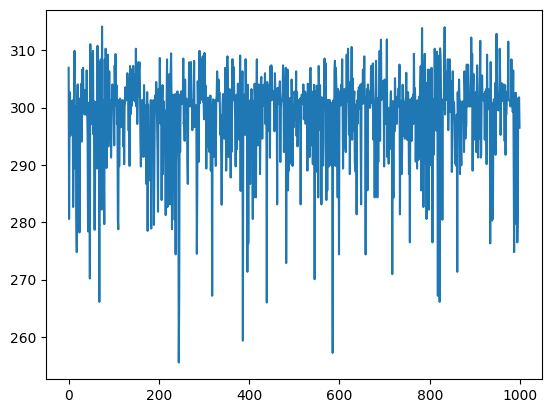

In [12]:
uk= cmd.query("pays== 'Royaume-Uni'")["ca"]
mediannes = []
moyennes = []
for i in range(1000):
  tirage= uk.sample(len(uk),replace= True, random_state=i)
  mediannes.append(tirage.median())
  moyennes.append(tirage.mean())

# Intervalle de confiance de la médiane
boot_uk_median = pd.Series(mediannes)
bas_uk_median = round(boot_uk_median.quantile(0.025), 2)
haut_uk_median = round(boot_uk_median.quantile(0.975), 2)
largeur_median = round(haut_uk_median - bas_uk_median, 2)

print(f"Intervalle de confiance de la médiane britannique : [{bas_uk_median}, {haut_uk_median}]")
print(f"Largeur de l'intervalle de la médiane : {largeur_median}")

# Intervalle de confiance de la moyenne
boot_uk_mean = pd.Series(moyennes)
bas_uk_mean = round(boot_uk_mean.quantile(0.025), 2)
haut_uk_mean = round(boot_uk_mean.quantile(0.975), 2)
largeur_mean = round(haut_uk_mean - bas_uk_mean, 2)

print(f"Intervalle de confiance de la moyenne britannique : [{bas_uk_mean}, {haut_uk_mean}]")
print(f"Largeur de l'intervalle de la moyenne : {largeur_mean}")

plt.plot(boot_uk_median)
plt.title("Distribution des médianes rééchantillonnées")
plt.show()

plt.plot(boot_uk_mean)
plt.title("Distribution des moyennes rééchantillonnées")
plt.show()

if largeur_median < largeur_mean:
    print(f"L'intervalle de confiance de la médiane ({largeur_median}) est plus étroit que celui de la moyenne ({largeur_mean}).")
    print("Cela suggère que la médiane est une mesure plus robuste de la tendance centrale pour ces données, car elle est moins sensible aux valeurs extrêmes (outliers) qui peuvent influencer la moyenne et élargir son intervalle de confiance.")
elif largeur_mean < largeur_median:
    print(f"L'intervalle de confiance de la moyenne ({largeur_mean}) est plus étroit que celui de la médiane ({largeur_median}).")
    print("Cela suggère que la moyenne est une mesure plus stable de la tendance centrale pour ces données. La médiane peut être plus variable que la moyenne si la distribution est symétrique et ne contient pas beaucoup d'outliers, ou si l'échantillon est petit.")
else:
    print(f"Les intervalles de confiance de la médiane et de la moyenne ont une largeur similaire ({largeur_median}).")

### Question 10 — Le jeudi est-il vraiment meilleur ?

> **Votre mission :**
> - Le jeudi concentre le plus de commandes. Les paniers y sont-ils aussi plus élevés que le reste de la semaine ?
> - Comparer les paniers du jeudi à ceux de tous les autres jours réunis.
> - Attention à la formulation de votre conclusion.

### Question 11 — Un test qui ne suppose pas de moyenne

> **Votre mission :**
> - Le test t compare des **moyennes** — or vous savez depuis la séance 3.1 que la moyenne décrit mal ces paniers.
> - Refaire la comparaison France / Allemagne avec un test de **Mann-Whitney**.
> - Les deux tests concluent-ils pareil ?
> - *Nouveau :* `stats.mannwhitneyu(a, b)`.

> 📖 **Le test de Mann-Whitney.** Il répond à : en tirant une commande de
> chaque pays, laquelle a le plus de chances d'être la plus grosse ? Sa
> méthode : ranger les commandes des deux pays dans un seul classement, du plus
> petit panier au plus gros, et regarder si celles d'un pays occupent plutôt le
> haut. Il ne compare donc **ni les moyennes ni les médianes** : une commande
> énorme y compte pour une place, pas pour son montant — et c'est précisément
> ce qui le rend utile ici.
> [Wikipédia](https://fr.wikipedia.org/wiki/Test_de_Wilcoxon-Mann-Whitney)

### Question 12 — Le test irlandais, au bon niveau

> **Votre mission :**
> - Le test Royaume-Uni / Irlande vu en cours traitait 256 commandes comme 256 observations indépendantes.
> - Refaire l'analyse **au niveau du client** : le panier moyen de chaque client irlandais, puis de chaque client britannique.
> - Combien d'observations reste-t-il du côté irlandais ?
> - Puis **refaire le test t** sur ces observations-là, et comparer sa p-value à celle du cours (p < 0,001 sur les 256 commandes).

### Question 13 — Corriger le seuil quand on multiplie les tests

> **Votre mission :**
> - Comparer les dix principaux marchés deux à deux fait 45 tests. À 5 %, combien de « faux positifs » attendrait-on par pur hasard ?
> - La correction de **Bonferroni** consiste à diviser le seuil par le nombre de tests. Calculer le seuil corrigé.
> - Compter combien de comparaisons restent significatives avec l'ancien seuil, puis avec le nouveau.
> - Combien en perdez-vous entre les deux ? C'est le prix de la correction.
> - *Nouveau :* `itertools.combinations(liste, 2)` énumère toutes les paires.

### Question 14 — L'effectif qu'il aurait fallu

> **Votre mission :**
> - L'écart France / Allemagne de 10,71 € n'est pas détectable sur 250 commandes de chaque côté. Combien en aurait-il fallu ?
> - Plutôt que de tâtonner, on peut calculer directement l'effectif nécessaire.
> - Il vaut environ `2 * (1.96 * ecart_type / ecart)**2` par groupe, où `ecart_type` est la dispersion typique des deux marchés et **`ecart` la différence entre les deux moyennes** — l'écart de 10,71 € qu'on cherche à détecter.
> - Combien de commandes par pays aurait-il fallu ? Rapportez ce nombre aux 250 dont vous disposez.

### Question 15 — La note de synthèse

> **Votre mission :**
> - Un dirigeant vous écrit : *« L'Irlande fait un panier 2,6 fois supérieur au Royaume-Uni et c'est statistiquement prouvé (p < 0,001). Répliquons le modèle irlandais partout. »*
> - Produire les trois chiffres qui montrent pourquoi cette phrase ne tient pas.
> - Puis rédigez votre réponse en commentaire, en trois phrases.